In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [4]:
data_path = "../data/synthetic/player_performance.csv"
df = pd.read_csv(data_path)
df.head()

,accuracy,time_played,deaths,score,performance
0,62.472407,30.364622,6,596.787369,1
1,97.042858,69.609104,2,1108.251431,2
2,83.919637,106.024042,13,851.999958,2
3,75.919509,90.544738,9,743.118369,1
4,49.361118,98.721726,15,417.980218,0


In [5]:
X = df[["accuracy","time_played","deaths"]]
y = df["performance"]
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1000, 3)
Target shape: (1000,)


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (800, 3)
Test size: (200, 3)


In [7]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    multi_class="auto"
)

model.fit(X_train, y_train)

print("Model training complete.")


Model training complete.


In [8]:
y_pred = model.predict(X_test)

y_pred[:10]


array([1, 2, 0, 1, 1, 0, 2, 0, 1, 1], dtype=int64)

In [9]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.84

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.83      0.86        66
           1       0.73      0.82      0.77        66
           2       0.92      0.87      0.89        68

    accuracy                           0.84       200
   macro avg       0.85      0.84      0.84       200
weighted avg       0.85      0.84      0.84       200



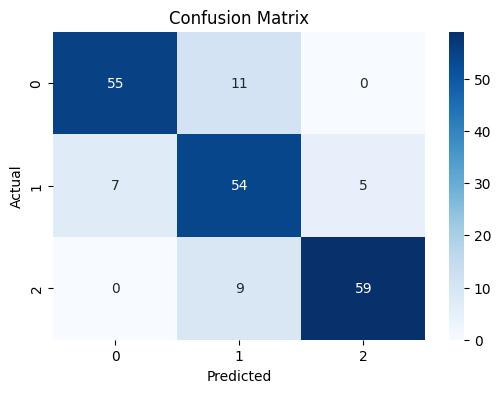

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [11]:
feature_names = X.columns
for i, class_coef in enumerate(model.coef_):
    print(f"\nClass {i} coefficients:")
    for name, coef in zip(feature_names, class_coef):
        print(f"  {name}: {coef:.3f}")



Class 0 coefficients:
  accuracy: -0.355
  time_played: -0.072
  deaths: 0.555

Class 1 coefficients:
  accuracy: 0.003
  time_played: 0.003
  deaths: -0.005

Class 2 coefficients:
  accuracy: 0.352
  time_played: 0.069
  deaths: -0.550
